# Classification of emotions

## Importing the libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab.patches import cv2_imshow
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization

## Loading the images

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Computer-Vision/Datasets/fer2013_2_classes.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

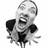

In [4]:
tf.keras.preprocessing.image.load_img('/content/fer2013_2_classes/train/Angry/1003.jpg')

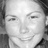

In [5]:
image = tf.keras.preprocessing.image.load_img('/content/fer2013_2_classes/train/Happy/1.jpg')
image

### Train and test set

In [6]:
training_generator = ImageDataGenerator(rescale=1./255,
                                        rotation_range=7,
                                        horizontal_flip=True,
                                        zoom_range=0.2)
train_dataset = training_generator.flow_from_directory('/content/fer2013_2_classes/train',
                                                        target_size = (48, 48),
                                                        batch_size = 16,
                                                        class_mode = 'categorical',
                                                        shuffle = True)

Found 11210 images belonging to 2 classes.


In [7]:
train_dataset.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [8]:
np.unique(train_dataset.classes, return_counts=True)

(array([0, 1], dtype=int32), array([3995, 7215]))

In [9]:
train_dataset.class_indices

{'Angry': 0, 'Happy': 1}

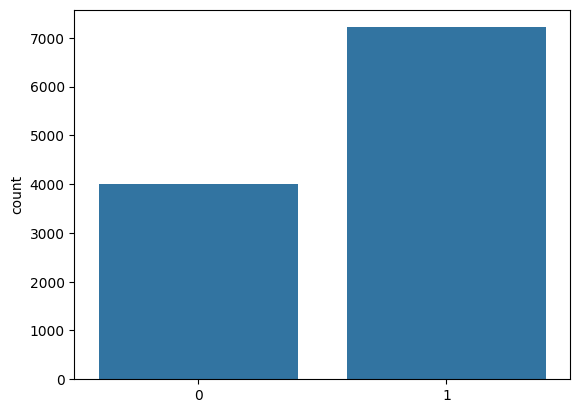

In [10]:
sns.countplot(x = train_dataset.classes);

In [11]:
test_generator = ImageDataGenerator(rescale=1./255)
test_dataset = test_generator.flow_from_directory('/content/fer2013_2_classes/validation',
                                                  target_size = (48, 48),
                                                  batch_size = 1,
                                                  class_mode = 'categorical',
                                                  shuffle = False)

Found 1370 images belonging to 2 classes.


## Building and training the convolutional neural network

In [12]:
num_detectors = 32
num_classes = 2
width, height = 48, 48
epochs = 50

network = Sequential()

network.add(Conv2D(num_detectors, (3, 3), activation = 'relu', padding = 'same', input_shape = (width, height, 3)))
network.add(BatchNormalization())
network.add(Conv2D(num_detectors, (3, 3), activation = 'relu', padding = "same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Conv2D(2*2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(Conv2D(2*2*2*num_detectors, (3, 3), activation = 'relu', padding="same"))
network.add(BatchNormalization())
network.add(MaxPooling2D(pool_size=(2, 2)))
network.add(Dropout(0.2))

network.add(Flatten())
network.add(Dense(2*num_detectors, activation = 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(2*num_detectors, activation = 'relu'))
network.add(BatchNormalization())
network.add(Dropout(0.2))

network.add(Dense(num_classes, activation='softmax'))

print(network.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,328,418 (5.07 MB)

 Trainable params: 1,326,242 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


In [13]:
network.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [14]:
network.fit(train_dataset, epochs=epochs)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


701/701 ━━━━━━━━━━━━━━━━━━━━ 43s 36ms/step - accuracy: 0.5852 - loss: 0.7617
Epoch 2/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6719 - loss: 0.6017
Epoch 3/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7789 - loss: 0.4606
Epoch 4/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8301 - loss: 0.3828
Epoch 5/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8394 - loss: 0.3610
Epoch 6/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8580 - loss: 0.3306
Epoch 7/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8644 - loss: 0.3174
Epoch 8/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8755 - loss: 0.3015
Epoch 9/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8743 - loss: 0.2955
Epoch 10/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.8792 - loss: 0.2888
Epoch 11/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.8911 - loss: 0.2737
Epoch 12/50
701/701 ━━━━━━━━━━━━━━━━━━━━ 

## Evaluating the neural network

In [15]:
network.evaluate(test_dataset)

1370/1370 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8974 - loss: 0.2727


[0.19545474648475647, 0.9262773990631104]

In [16]:
predictions = network.predict(test_dataset)
predictions

1370/1370 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


array([[9.9240428e-01, 7.5956536e-03],
       [9.9977666e-01, 2.2329645e-04],
       [9.9675024e-01, 3.2497980e-03],
       ...,
       [7.7587145e-04, 9.9922407e-01],
       [1.5972910e-08, 1.0000000e+00],
       [2.7166048e-05, 9.9997282e-01]], dtype=float32)

In [17]:
predictions = np.argmax(predictions, axis = 1)
predictions

array([0, 0, 0, ..., 1, 1, 1])

In [18]:
test_dataset.classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(test_dataset.classes, predictions)

0.9262773722627737

In [20]:
test_dataset.class_indices

{'Angry': 0, 'Happy': 1}

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_dataset.classes, predictions)
cm

array([[436,  55],
       [ 46, 833]])

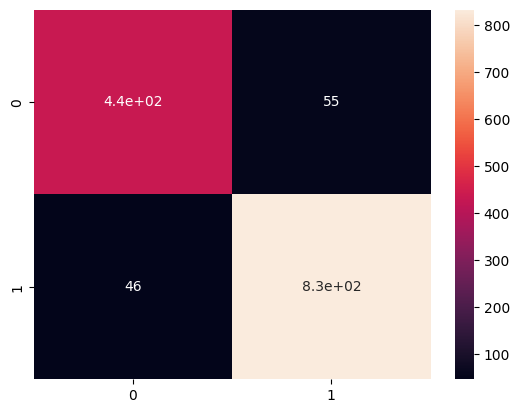

In [22]:
sns.heatmap(cm, annot=True);

In [23]:
from sklearn.metrics import classification_report
print(classification_report(test_dataset.classes, predictions))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       491
           1       0.94      0.95      0.94       879

    accuracy                           0.93      1370
   macro avg       0.92      0.92      0.92      1370
weighted avg       0.93      0.93      0.93      1370

